In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv('ai_resume_screening.csv')
df

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes
...,...,...,...,...,...,...,...
29995,9,77.4,Bachelors,13,691,434,Yes
29996,5,77.8,Bachelors,9,473,149,No
29997,1,64.6,Bachelors,7,247,82,No
29998,7,94.8,Bachelors,12,584,409,Yes


In [ ]:
print(df.shape)
print(df.info())
print(df.isna().sum())
print(df.duplicated().sum())


(30000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  object 
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.6+ MB
None
years_experience      0
skills_match_score    0
education_level       0
project_count         0
resume_length         0
github_activity       0
shortlisted           0
dtype: int64
0


In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)


Numerical Columns: Index(['years_experience', 'skills_match_score', 'project_count',
       'resume_length', 'github_activity'],
      dtype='object')
Categorical Columns: Index(['education_level', 'shortlisted'], dtype='object')


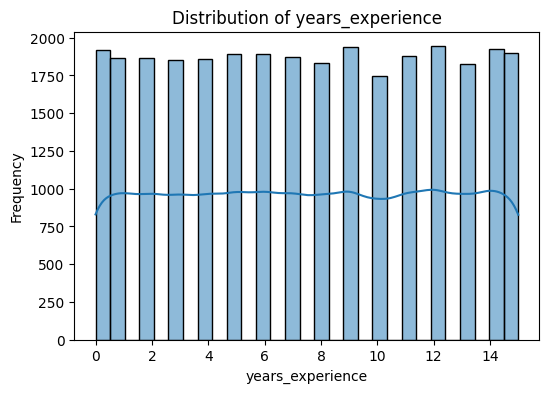

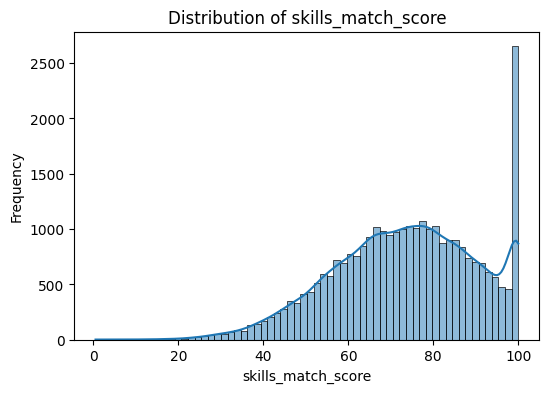

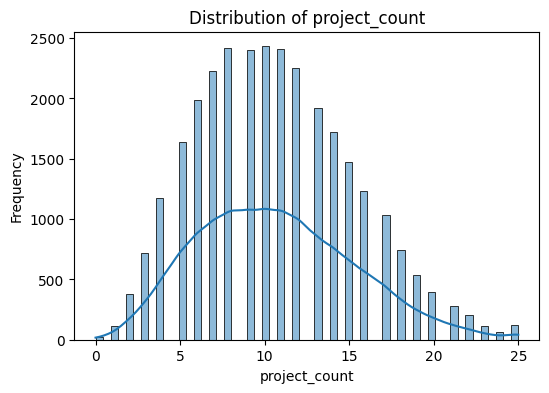

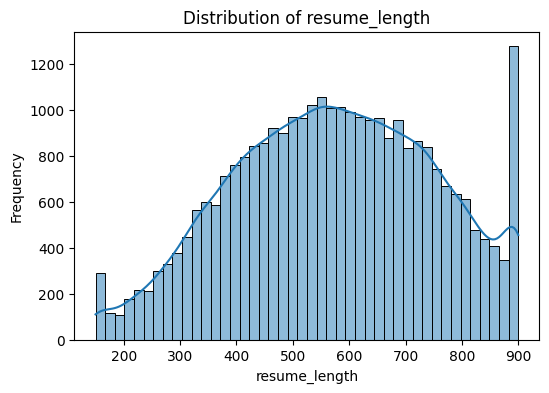

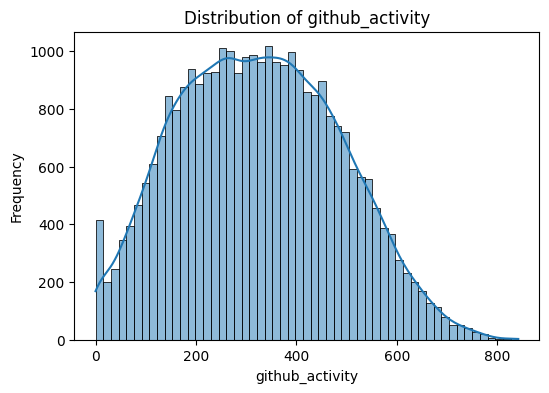

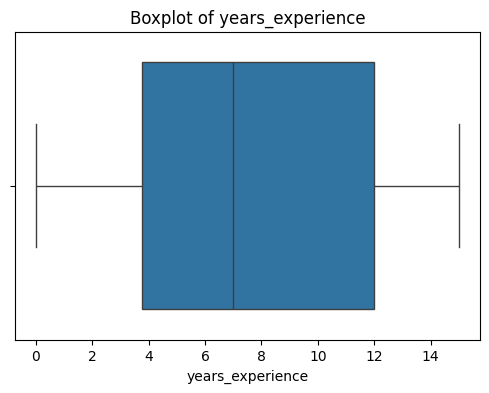

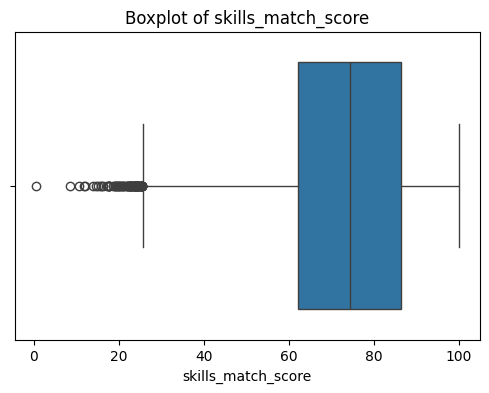

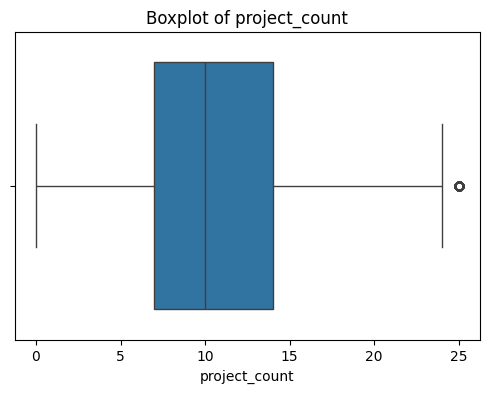

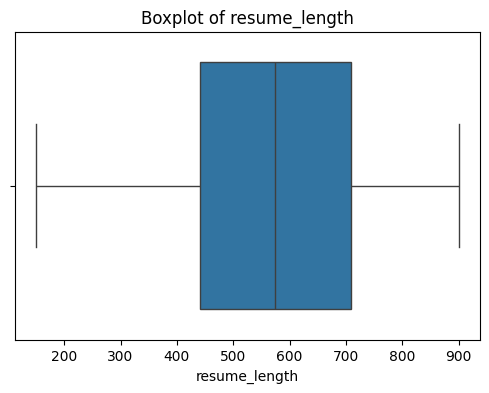

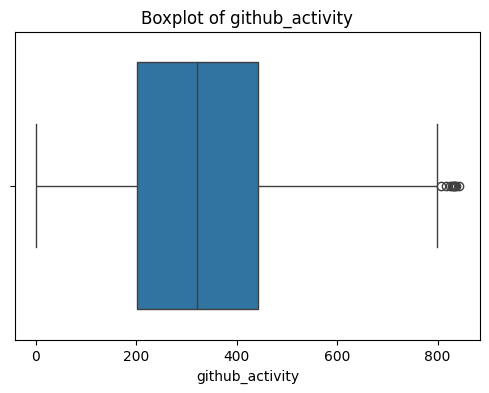

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()




Value counts for education_level:
education_level
Bachelors      13461
Masters        10524
PhD             3024
High School     2991
Name: count, dtype: int64

Value counts for shortlisted:
shortlisted
Yes    20966
No      9034
Name: count, dtype: int64


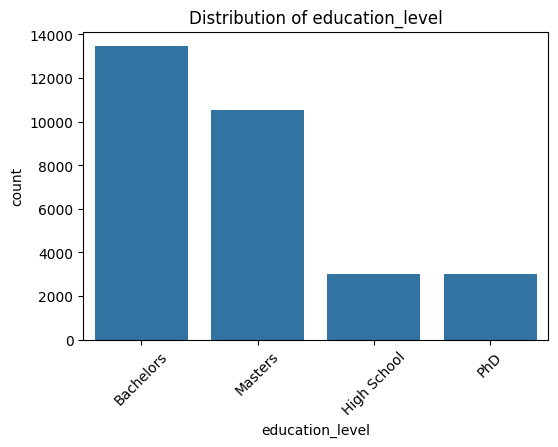

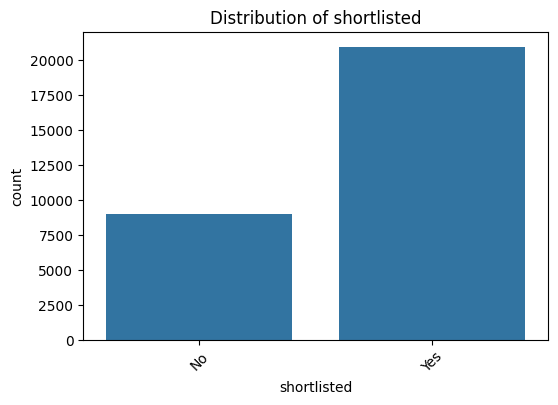

In [ ]:
for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()



Average years_experience by shortlisted:
shortlisted
No     2.682311
Yes    9.585281
Name: years_experience, dtype: float64

Average skills_match_score by shortlisted:
shortlisted
No     60.672703
Yes    79.288486
Name: skills_match_score, dtype: float64

Average project_count by shortlisted:
shortlisted
No      6.413992
Yes    12.469904
Name: project_count, dtype: float64

Average resume_length by shortlisted:
shortlisted
No     430.335510
Yes    633.878184
Name: resume_length, dtype: float64

Average github_activity by shortlisted:
shortlisted
No     167.654749
Yes    393.171182
Name: github_activity, dtype: float64


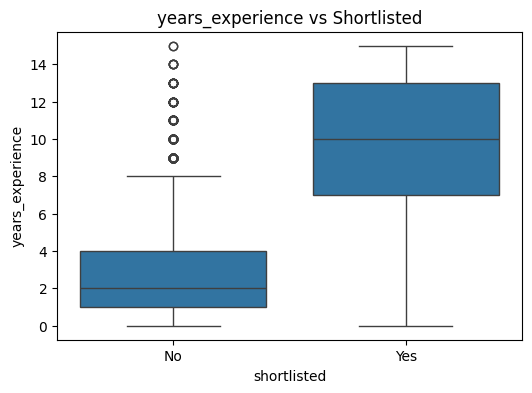

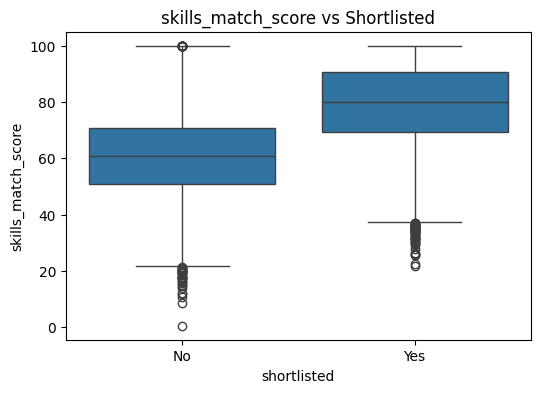

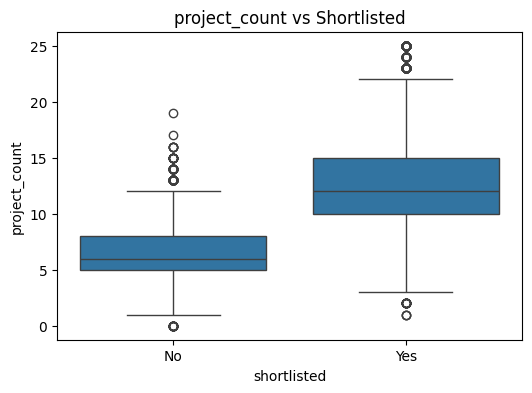

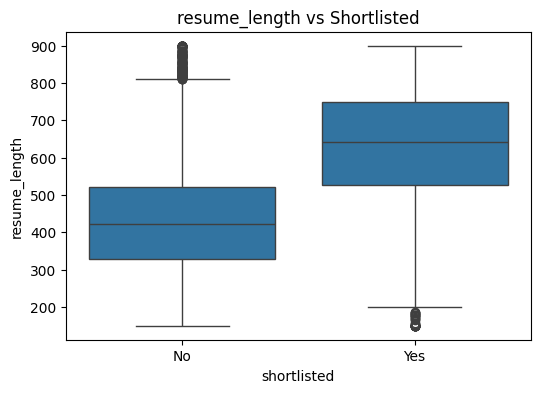

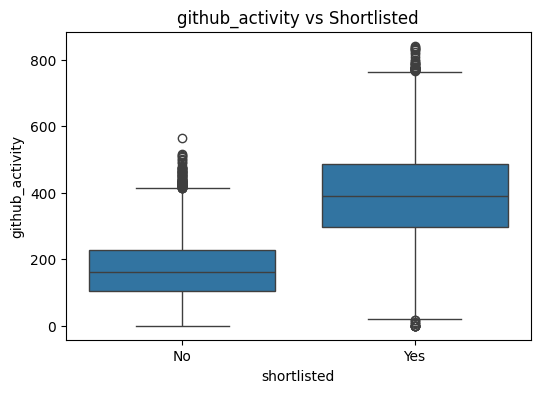

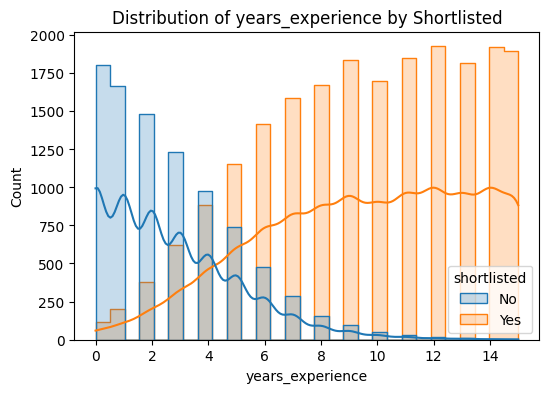

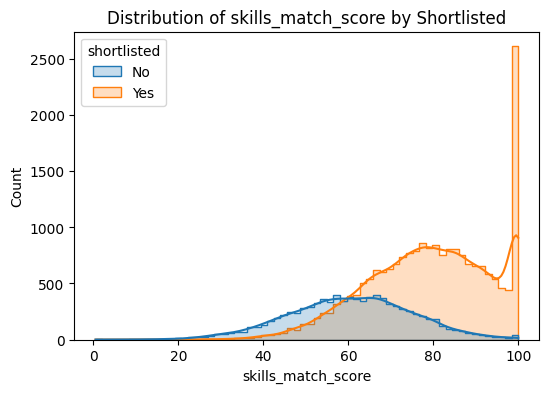

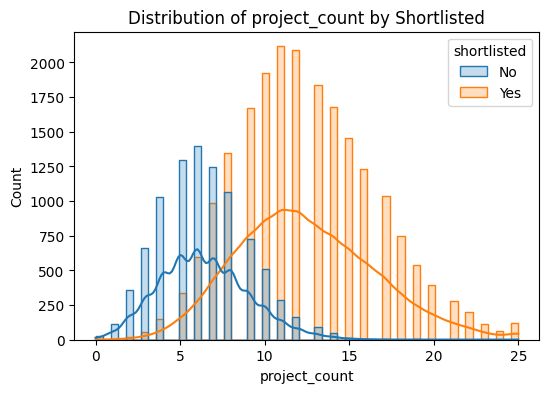

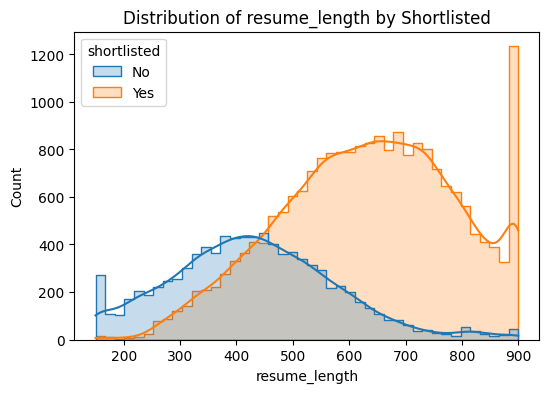

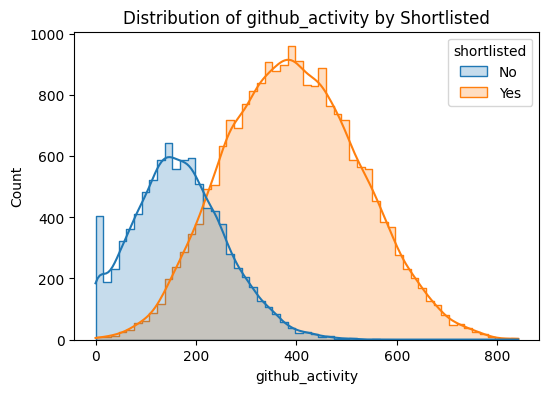

In [ ]:
for col in numerical_cols:
    print(f"\nAverage {col} by shortlisted:")
    print(df.groupby('shortlisted')[col].mean())

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='shortlisted', y=col, data=df)
    plt.title(f"{col} vs Shortlisted")
    plt.show()

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue='shortlisted', kde=True, element='step')
    plt.title(f"Distribution of {col} by Shortlisted")
    plt.show()



Crosstab for education_level:
shortlisted            No       Yes
education_level                    
Bachelors        0.341282  0.658718
High School      0.456035  0.543965
Masters          0.248575  0.751425
PhD              0.152116  0.847884

Crosstab for shortlisted:
shortlisted   No  Yes
shortlisted          
No           1.0  0.0
Yes          0.0  1.0


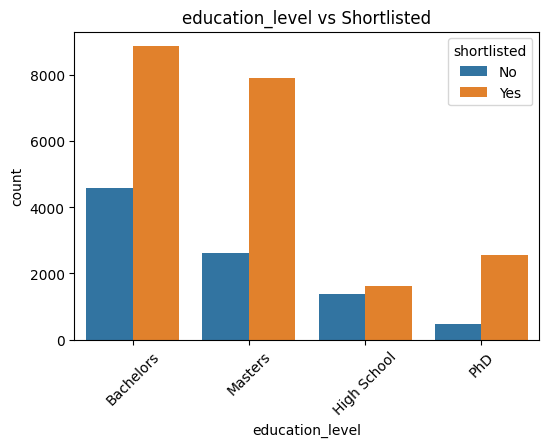

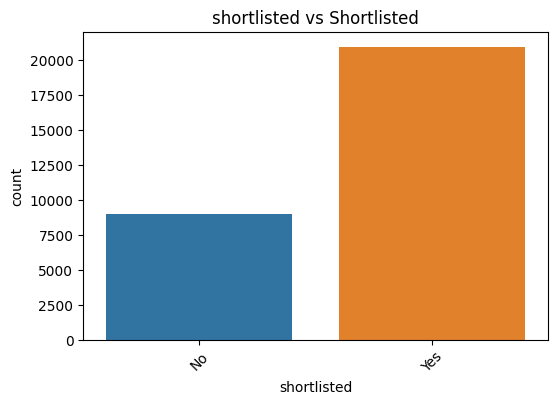

In [ ]:
for col in categorical_cols:
    print(f"\nCrosstab for {col}:")
    print(pd.crosstab(df[col], df['shortlisted'], normalize='index'))

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='shortlisted', data=df)
    plt.title(f"{col} vs Shortlisted")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
df['shortlisted'] = df['shortlisted'].map({'No':0, 'Yes':1})
df = pd.get_dummies(df, columns=['education_level'], drop_first=True)

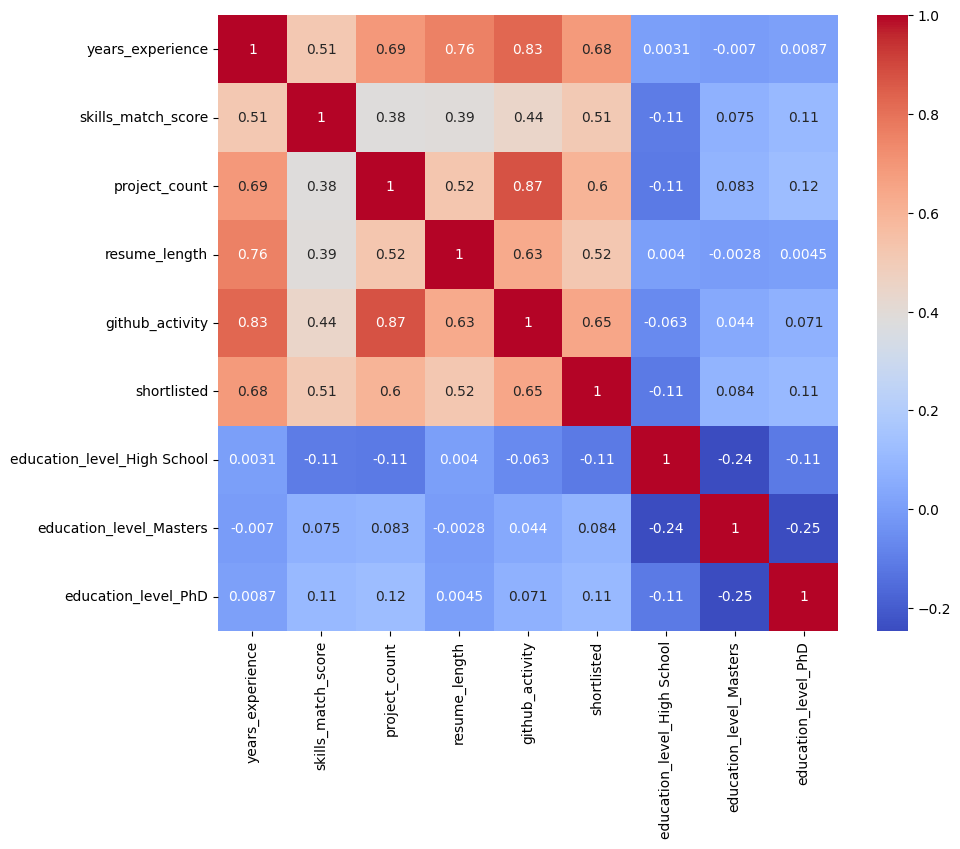

In [ ]:
corr = df.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

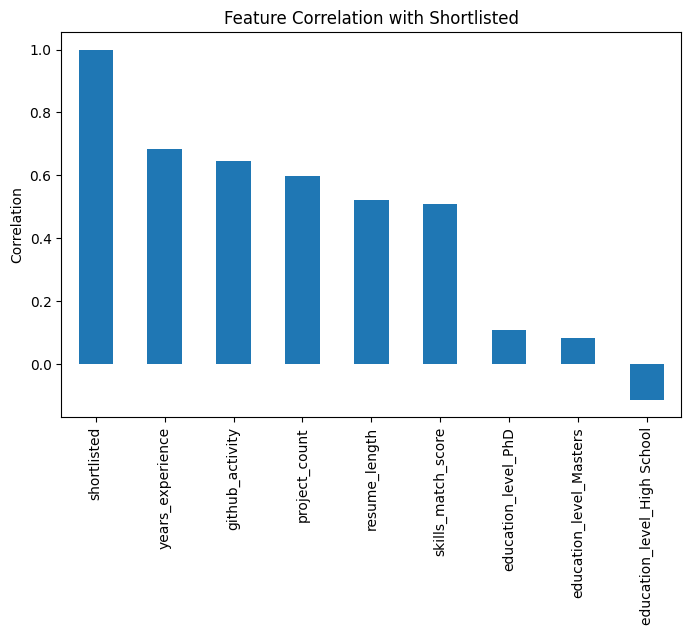

In [ ]:
corr_with_target.plot(kind='bar', figsize=(8,5))
plt.title("Feature Correlation with Shortlisted")
plt.ylabel("Correlation")
plt.show()

In [ ]:
X = df.drop("shortlisted", axis=1)
y = df["shortlisted"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
y_pred_rf = rf.predict(X_test)

Logistic Regression Accuracy: 0.9063


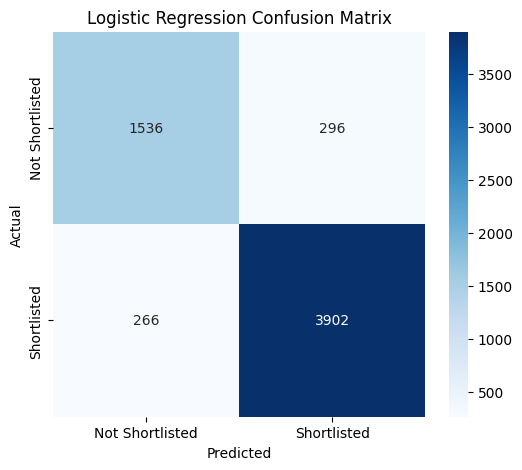


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1832
           1       0.93      0.94      0.93      4168

    accuracy                           0.91      6000
   macro avg       0.89      0.89      0.89      6000
weighted avg       0.91      0.91      0.91      6000



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Shortlisted', 'Shortlisted'],
            yticklabels=['Not Shortlisted', 'Shortlisted'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Random Forest Accuracy: 0.8977


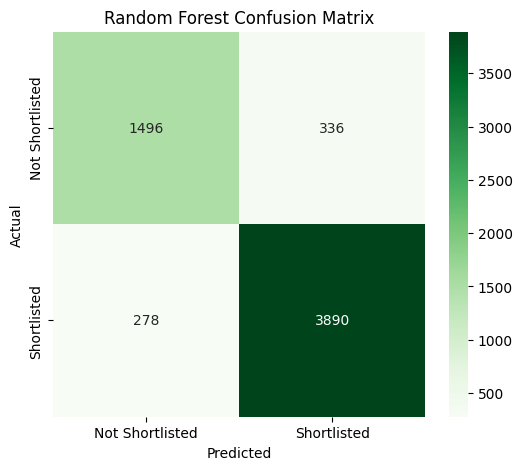


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1832
           1       0.92      0.93      0.93      4168

    accuracy                           0.90      6000
   macro avg       0.88      0.87      0.88      6000
weighted avg       0.90      0.90      0.90      6000



In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Shortlisted', 'Shortlisted'],
            yticklabels=['Not Shortlisted', 'Shortlisted'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid,
                       cv=5,
                       scoring='accuracy',
                       n_jobs=-1)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
best_rf = rf_grid.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))

Tuned Random Forest Accuracy: 0.9006666666666666


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs']
}

lr_grid = GridSearchCV(LogisticRegression(max_iter=1000),
                       param_grid_lr,
                       cv=5,
                       scoring='accuracy')

lr_grid.fit(X_train_scaled, y_train)

print("Best Logistic Parameters:", lr_grid.best_params_)

Best Logistic Parameters: {'C': 0.01, 'solver': 'lbfgs'}


In [ ]:
best_lr = lr_grid.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test_scaled)

print("Tuned Logistic Accuracy:", accuracy_score(y_test, y_pred_lr_tuned))

Tuned Logistic Accuracy: 0.9058333333333334
